In [190]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)


In [191]:
val_df   = pd.read_csv("data/val.csv")
target = "TriageGrade"
y_test = val_df[target]

models_to_test = [
    "models/models/baseline.joblib",
    "models/models/decision_tree.joblib",
    "models/models/decision_tree_new.joblib",
    "models/models/decision_tree_new_weight.joblib",
    "models/models/modelo_logreg_multi.joblib",
    "models/models/modelo_logreg_multi_new.joblib",
    "models/models/modelo_logreg_multi_new_weight.joblib",
    'models/models/random_forest.joblib',
    'models/models/random_forest_new.joblib',
    'models/models/random_forest_new_weight.joblib',
]

CLASS_PRIORITY = 4
TARGET_RECALL = 0.90

In [192]:
def precision_at_target_recall(y_true, probas, target_recall):
    precision, recall, thresholds = precision_recall_curve(y_true, probas)

    valid = np.where(recall >= target_recall)[0]
    if len(valid) == 0:
        return 0.0, 1.0

    best = valid[np.argmax(precision[valid])]
    threshold = thresholds[best] if best < len(thresholds) else 1.0

    return float(precision[best]), float(threshold)


In [193]:
def plot_confusion(y_true, preds, ax, title):
    cm = confusion_matrix(y_true, preds, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")


In [194]:
def plot_pr(y_true, probas, ax, title):
    classes = np.unique(y_true)
    idx = list(classes).index(CLASS_PRIORITY)

    y_bin = (y_true == CLASS_PRIORITY).astype(int)
    precision, recall, _ = precision_recall_curve(y_bin, probas[:, idx])

    ax.plot(recall, precision)
    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True)


In [195]:
def plot_threshold(y_true, probas, ax, title):
    classes = np.unique(y_true)
    idx = list(classes).index(CLASS_PRIORITY)

    y_bin = (y_true == CLASS_PRIORITY).astype(int)
    probs = probas[:, idx]

    thresholds = np.linspace(0, 1, 100)
    recalls, precisions = [], []

    for th in thresholds:
        preds = (probs >= th).astype(int)
        recalls.append(recall_score(y_bin, preds, zero_division=0))
        precisions.append(precision_score(y_bin, preds, zero_division=0))

    ax.plot(thresholds, recalls, label="Recall")
    ax.plot(thresholds, precisions, label="Precision")
    ax.axvline(0.5, color="red", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.legend()
    ax.grid(True)


In [196]:
def evaluate_model(path, X_df, y_true):
    data = joblib.load(path)
    model = data["model"]
    features = data["features"]
    name = path.split("/")[-1]

    X = X_df[features]

    preds = model.predict(X)
    probas = model.predict_proba(X)

    report = classification_report(y_true, preds, output_dict=True, zero_division=0)

    # Métricas globais
    accuracy = accuracy_score(y_true, preds)
    f1_w = f1_score(y_true, preds, average="weighted", zero_division=0)

    # Classe 4
    classes = np.unique(y_true)
    idx = list(classes).index(CLASS_PRIORITY)
    y_bin = (y_true == CLASS_PRIORITY).astype(int)
    probas_c4 = probas[:, idx]

    ap = average_precision_score(y_bin, probas_c4)
    prec_target, th_target = precision_at_target_recall(
        y_bin, probas_c4, TARGET_RECALL
    )

    metrics = {
        "model": name,
        "accuracy": accuracy,
        "f1_weighted": f1_w,
        "recall_class_4": report[str(CLASS_PRIORITY)]["recall"],
        "average_precision_class_4": ap,
        f"precision_at_{TARGET_RECALL}_recall": prec_target,
        "threshold_for_target_recall": th_target
    }

    return metrics, preds, probas


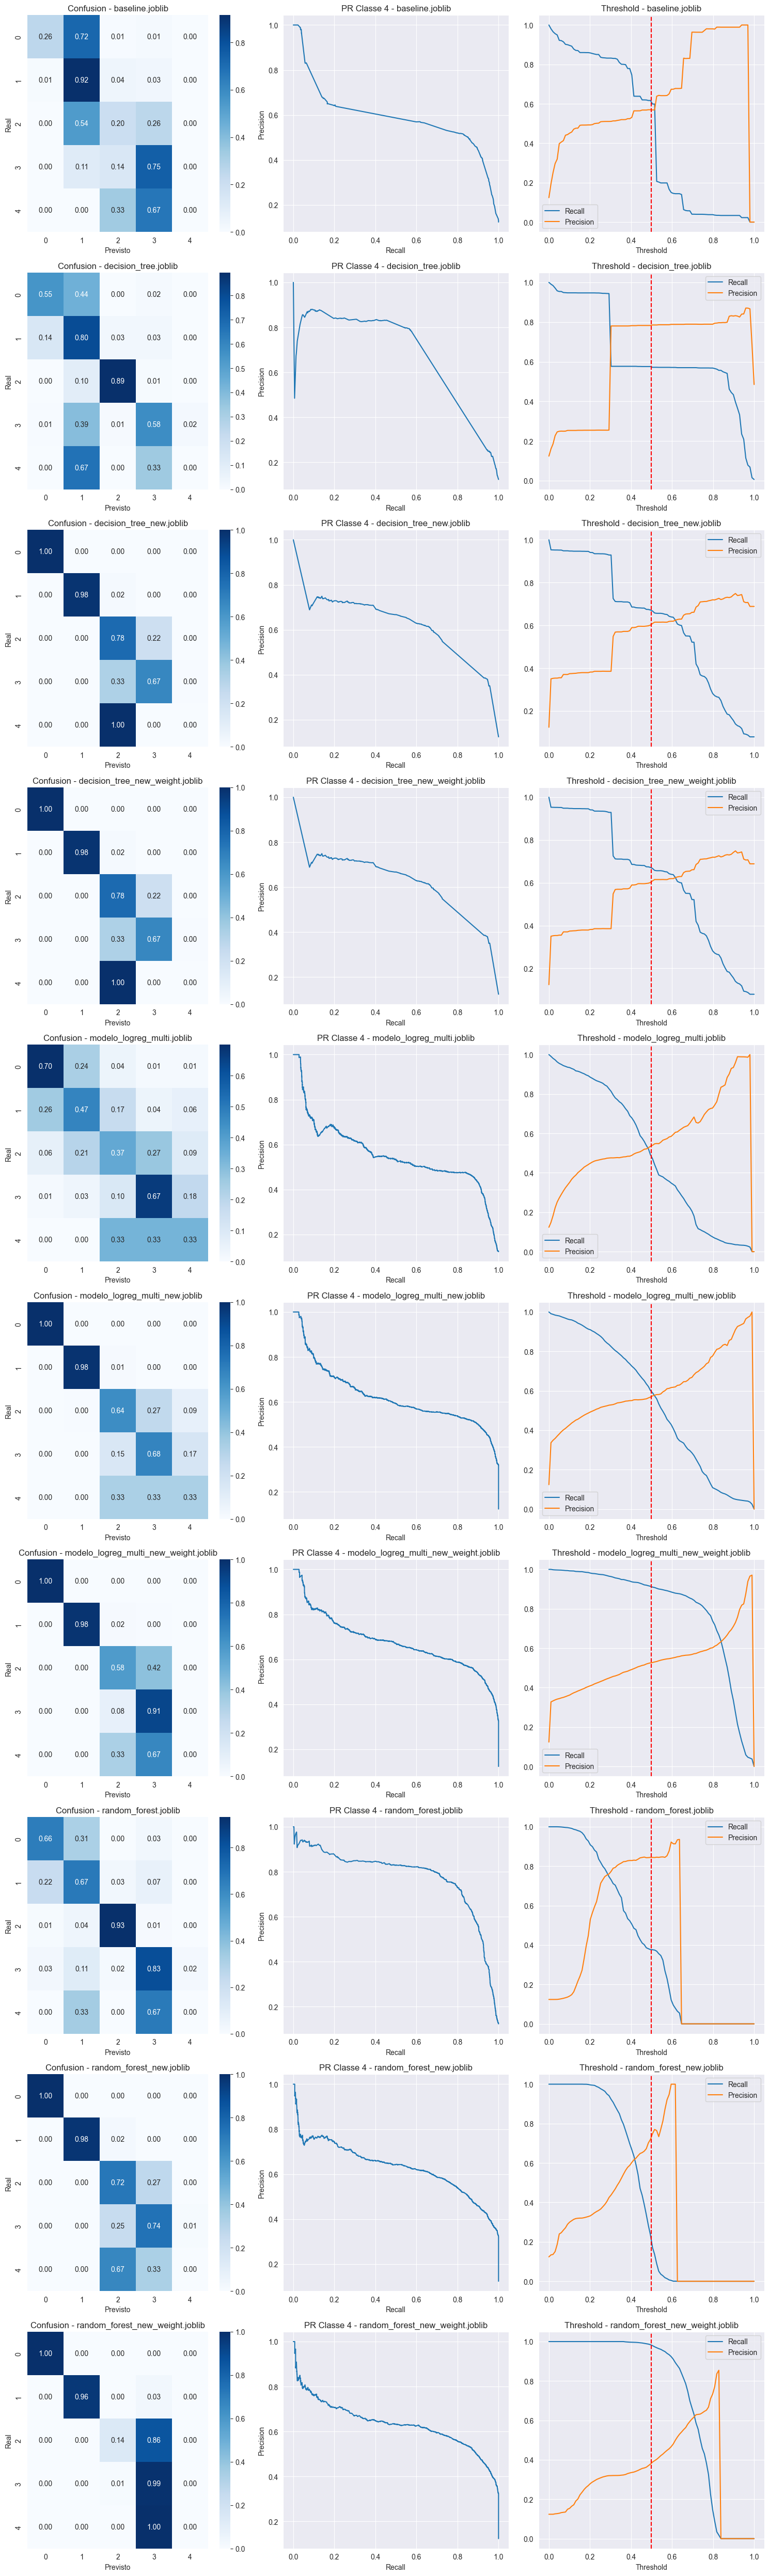

In [197]:
results = []

num_models = len(models_to_test)
fig, axes = plt.subplots(num_models, 3, figsize=(15, 5 * num_models))

for i, path in enumerate(models_to_test):
    metrics, preds, probas = evaluate_model(path, val_df, y_test)
    results.append(metrics)

    name = metrics["model"]

    plot_confusion(y_test, preds, axes[i, 0], f"Confusion - {name}")
    plot_pr(y_test, probas, axes[i, 1], f"PR Classe 4 - {name}")
    plot_threshold(y_test, probas, axes[i, 2], f"Threshold - {name}")

plt.tight_layout()
plt.show()


In [198]:
df_final = pd.DataFrame(results)

df_final = df_final.sort_values(
    by=["recall_class_4", f"precision_at_{TARGET_RECALL}_recall"],
    ascending=False
)

print(df_final)
df_final.to_csv("model_comparison.csv", index=False)


                                   model  accuracy  f1_weighted  \
9        random_forest_new_weight.joblib  0.773457     0.749855   
6  modelo_logreg_multi_new_weight.joblib  0.878216     0.881167   
7                   random_forest.joblib  0.752477     0.774641   
0                        baseline.joblib  0.676792     0.633254   
8               random_forest_new.joblib  0.888775     0.892867   
5         modelo_logreg_multi_new.joblib  0.865842     0.883513   
4             modelo_logreg_multi.joblib  0.488440     0.524986   
2               decision_tree_new.joblib  0.894311     0.896489   
3        decision_tree_new_weight.joblib  0.894311     0.896489   
1                   decision_tree.joblib  0.775922     0.784592   

   recall_class_4  average_precision_class_4  precision_at_0.9_recall  \
9        0.992105                   0.632854                 0.493611   
6        0.914662                   0.676625                 0.537253   
7        0.826316                   0.77661